# Instagram Likes Report

Name: Addy Mager

Date: September 2026

Source: Distinguishes between you (who generated the underlying behavior- the likes themselves) and Instagram/Meta (who recorded, structured, and exported the data into the JSON files).

Purpose: Notes Instagram's own reason for creating the data (powering recommendations/ads) versus why it's made available to you (portability/privacy compliance), separate from your reason for using it here.

Reliability: Comes straight from the platform's own logs, not self-report, and covers every recorded like. 

Unreliability: No info on why you liked something, unknown export completeness, and the garbled emoji/text encoding issues you'll actually see in the data. 

In [1]:
import json 
import pandas as pd

with open('liked_posts.json', 'r') as f:
  data = json.load(f)

data[0]

{'timestamp': 1788348855,
 'media': [],
 'label_values': [{'label': 'URL',
   'value': 'https://www.instagram.com/reel/DcxTA5CI9-m/',
   'href': 'https://www.instagram.com/reel/DcxTA5CI9-m/'},
  {'label': 'Caption',
   'value': 'Skincare routine pt 2 ð\x9f\x8c\x9fð\x9f\x8c\x9f\n\n@dermalogica @tatcha @graceandstella @cleanskinclub \n\n#skincare #skincareroutine #nighttimeskincareroutine #nighttimeskincare #explorepageâ\x9c¨'},
  {'label': 'Title', 'value': ''},
  {'dict': [{'dict': [{'label': 'Name', 'value': 'explorepageâ\x9c¨'}],
     'title': ''},
    {'dict': [{'label': 'Name', 'value': 'skincare'}], 'title': ''},
    {'dict': [{'label': 'Name', 'value': 'nighttimeskincare'}], 'title': ''},
    {'dict': [{'label': 'Name', 'value': 'nighttimeskincareroutine'}],
     'title': ''},
    {'dict': [{'label': 'Name', 'value': 'skincareroutine'}], 'title': ''}],
   'title': 'Hashtags'},
  {'dict': [{'dict': [{'label': 'URL', 'value': 'https://hoo.be/paigewade19'},
      {'label': 'Name', '

In [2]:
row = {}
row['timestamp'] = data[0]['timestamp']

row

{'timestamp': 1788348855}

In [3]:
for item in data[0]['label_values']:
    if 'label' in item:
        row[item['label']] = item['value']

row

{'timestamp': 1788348855,
 'URL': 'https://www.instagram.com/reel/DcxTA5CI9-m/',
 'Caption': 'Skincare routine pt 2 ð\x9f\x8c\x9fð\x9f\x8c\x9f\n\n@dermalogica @tatcha @graceandstella @cleanskinclub \n\n#skincare #skincareroutine #nighttimeskincareroutine #nighttimeskincare #explorepageâ\x9c¨',
 'Title': ''}

In [4]:
for item in data[0]['label_values']:
    if 'label' in item:
        row[item['label']] = item['value']
    elif item.get('title') == 'Owner':
        owner_fields = item['dict'][0]['dict']
        for owner_item in owner_fields:
            row['Owner ' + owner_item['label']] = owner_item['value']

row

{'timestamp': 1788348855,
 'URL': 'https://www.instagram.com/reel/DcxTA5CI9-m/',
 'Caption': 'Skincare routine pt 2 ð\x9f\x8c\x9fð\x9f\x8c\x9f\n\n@dermalogica @tatcha @graceandstella @cleanskinclub \n\n#skincare #skincareroutine #nighttimeskincareroutine #nighttimeskincare #explorepageâ\x9c¨',
 'Title': '',
 'Owner URL': 'https://hoo.be/paigewade19',
 'Owner Name': 'Paige Wade',
 'Owner Username': 'paigemwade'}

In [5]:
tidy_rows = []

for entry in data:
    row = {}
    row['timestamp'] = entry['timestamp']

    for item in entry['label_values']:
        if 'label' in item:
            row[item['label']] = item['value']
        elif item.get('title') == 'Owner':
            owner_fields = item['dict'][0]['dict']
            for owner_item in owner_fields:
                row['Owner ' + owner_item['label']] = owner_item['value']

    tidy_rows.append(row)

tidy_rows[:2]

[{'timestamp': 1788348855,
  'URL': 'https://www.instagram.com/reel/DcxTA5CI9-m/',
  'Caption': 'Skincare routine pt 2 ð\x9f\x8c\x9fð\x9f\x8c\x9f\n\n@dermalogica @tatcha @graceandstella @cleanskinclub \n\n#skincare #skincareroutine #nighttimeskincareroutine #nighttimeskincare #explorepageâ\x9c¨',
  'Title': '',
  'Owner URL': 'https://hoo.be/paigewade19',
  'Owner Name': 'Paige Wade',
  'Owner Username': 'paigemwade'},
 {'timestamp': 1788347338,
  'URL': 'https://www.instagram.com/p/Dcv739FIN7y/',
  'Caption': 'September plans in Northeast Ohio are officially looking good. ð\x9f\x93\x8d\n\nI rounded up the local happenings, places worth adding to your list, and a few things that deserve a spot on your calendar this month.\n\nConsider this your shortcut to figuring out what to do when the group chat hits you with, â\x80\x9cAny plans this weekend?â\x80\x9d\n\nSave this one for later and send it to your favorite person to explore Northeast Ohio with.\n\nComment FALL and Iâ\x80\x99ll send 

In [6]:
likes_df = pd.DataFrame(tidy_rows)
likes_df.head(10)

,timestamp,URL,Caption,Title,Owner URL,Owner Name,Owner Username
0,1788348855,https://www.instagram.com/reel/DcxTA5CI9-m/,Skincare routine pt 2 ðð\n\n@dermalogica...,,https://hoo.be/paigewade19,Paige Wade,paigemwade
1,1788347338,https://www.instagram.com/p/Dcv739FIN7y/,September plans in Northeast Ohio are official...,,https://lp.constantcontactpages.com/cu/chJbPOa...,Megan Weihrauch,megansells216
2,1788317405,https://www.instagram.com/reel/DcxMCfwIl9l/,Skincare routine pt 1. I cannot emphasize enou...,,https://hoo.be/paigewade19,Paige Wade,paigemwade
3,1788314918,https://www.instagram.com/p/DcxHcVHkbDfVrJakGC...,Smiles from summer!! ð,,,GRACE OSPELT,graceospelt
4,1788312957,https://www.instagram.com/reel/Dcw6C-HPI1x/,i donât wanna know,,https://lynxinbio.com/jpztd,Reese LeRoy,reese.paige.leroy
5,1788312936,https://www.instagram.com/p/Dcwv8-YNROY/,"Welcome back to Progressive Field, Biebs!\n\n#...",,https://linktr.ee/CLEGuardians,Cleveland Guardians,cleguardians
6,1788312922,https://www.instagram.com/reel/Dcw1mgupZ1w/,happy september 1stðð« #reels #reset #sat...,,https://www.youtube.com/@addigraceyt,Addi Grace,addigraceig
7,1788312216,https://www.instagram.com/p/DcxCcPjDiyx/,Top 10 beach days ðºð´,,https://linktr.ee/itskacylee,Kacy Lee,itskacylee
8,1788311650,https://www.instagram.com/p/DcxBSWHFjfK/,i smell pumpkin season.. but for now hereâs ...,,https://open.spotify.com/track/6xnpU9rBct5suXN...,Caroline Phillips,carolinemanning
9,1788311327,https://www.instagram.com/p/Dcw0nVoAFAP/,"Hi, September!",,http://sprout.link/snoopygrams/,Snoopy And The Peanuts Gang,snoopygrams


In [7]:
likes_df['DateTime'] = pd.to_datetime(likes_df['timestamp'], unit='s')
likes_df[['timestamp', 'DateTime']].head() 

,timestamp,DateTime
0,1788348855,2026-09-02 11:34:15
1,1788347338,2026-09-02 11:08:58
2,1788317405,2026-09-02 02:50:05
3,1788314918,2026-09-02 02:08:38
4,1788312957,2026-09-02 01:35:57


In [8]:
likes_df.shape

(19327, 8)

In [9]:
likes_df.dtypes

timestamp                 int64
URL                         str
Caption                     str
Title                       str
Owner URL                   str
Owner Name                  str
Owner Username              str
DateTime          datetime64[s]
dtype: object

In [10]:
likes_df.groupby("Owner Username")["DateTime"].count()

Owner Username
0626natalie               1
100percentvision          1
11.30pm                  18
1211mak                   3
1223334444.4444333221     1
                         ..
zookeeperjawnie           1
zrst4voiceovers_          1
zucatelli                 1
zuri.the.cocker           1
zzz92758                  2
Name: DateTime, Length: 3633, dtype: int64

In [11]:
likes_by_account = (
    likes_df.groupby("Owner Username")["DateTime"]
    .count()
    .sort_values(ascending=False)
)
likes_by_account.head(10)

Owner Username
chippythedogbooks    911
lexxhidalgo          692
yailenysr            688
cleguardians         627
kesley_leroy         516
reese.paige.leroy    499
klailea              390
caiti_mackenzie      358
imfromcleveland      292
itskacylee           282
Name: DateTime, dtype: int64

# Hypothesis

I hypothesize that my Instagram interactions are concentrated among certain accounts rather than being evenly distributed across all accounts.

The theoretical variable I am examining is interaction frequency by Instagram account. The statistical evidence will come from counting the number of interactions associated with each account and comparing those counts. If some accounts have substantially more interactions than others, this would provide evidence that my Instagram activity is concentrated among particular accounts.

The liked_comments.json dataset provides a second type of interaction that can be compared with my liked-post activity. Examining both datasets can show whether certain accounts appear repeatedly across different types of Instagram interactions.

# Second DataFrame

The DataFrame represents comments that I have liked on Instagram. Each row represents one liked comment, while the columns contain information about the account, the Instagram URL, the type of interaction, the timestamp, and the converted date and time.

The DataFrame follows tidy-data principles because each observation is represented by one row and each variable is represented by a separate column. The Account, URL, Like, timestamp, and DateTime columns each describe a different aspect of the interaction.

This data can be used to test my hypothesis because I can count the number of liked comments associated with each account. If some accounts have many more liked comments than others, this would show that my interactions are concentrated among particular accounts. However, the dataset cannot explain why I interacted with those accounts or whether I consider them favorites.

In [12]:
with open('liked_comments.json', 'r') as f:
    comments_data = json.load(f)

comments_data.keys()

dict_keys(['likes_comment_likes'])

In [13]:
rows = []

for entry in comments_data['likes_comment_likes']:
    row = {
        'Account': entry['title'],
        'URL': entry['string_list_data'][0]['href'],
        'Like': entry['string_list_data'][0]['value'],
        'timestamp': entry['string_list_data'][0]['timestamp']
    }
    
    rows.append(row)

comments_df = pd.DataFrame(rows)

comments_df['DateTime'] = pd.to_datetime(
    comments_df['timestamp'],
    unit='s'
)

comments_df.head(10)

,Account,URL,Like,timestamp,DateTime
0,michael_swish_09,https://www.instagram.com/p/Db53VUOkXnb/,ð,1786734814,2026-08-14 19:13:34
1,elianazein_,https://www.instagram.com/p/DYF0z7ckQ6E/,ð,1786538839,2026-08-12 12:47:19
2,ozziesgal1,https://www.instagram.com/p/DbBkRONIBxu/,ð,1784601114,2026-07-21 02:31:54
3,pendantwheat607,https://www.instagram.com/p/DbBkRONIBxu/,ð,1784572333,2026-07-20 18:32:13
4,allycat826,https://www.instagram.com/p/DZn4nOuEYQ2/,ð,1781577999,2026-06-16 02:46:39
5,mkatmag,https://www.instagram.com/p/DYp7L5gnfBV/,ð,1779538893,2026-05-23 12:21:33
6,shardzlee,https://www.instagram.com/p/DYp7L5gnfBV/,ð,1779505540,2026-05-23 03:05:40
7,keerthan.challa,https://www.instagram.com/p/DYcdRrwjW1f/,ð,1779037008,2026-05-17 16:56:48
8,abigail.morneau,https://www.instagram.com/p/DYKttTXkRVb/,ð,1778537823,2026-05-11 22:17:03
9,paige_chinn,https://www.instagram.com/p/DYKttTXkRVb/,ð,1778439798,2026-05-10 19:03:18


In [14]:
comment_likes_by_account = (
    comments_df.groupby('Account')
    .size()
    .sort_values(ascending=False)
)

comment_likes_by_account.head(10)

Account
mkatmag             9
shardzlee           8
magicanime21        3
paige_chinn         3
kesley_leroy        2
ozziesgal1          2
helenapaige_2021    2
grandrivervalley    2
giannahoff_         2
elialihan           2
dtype: int64

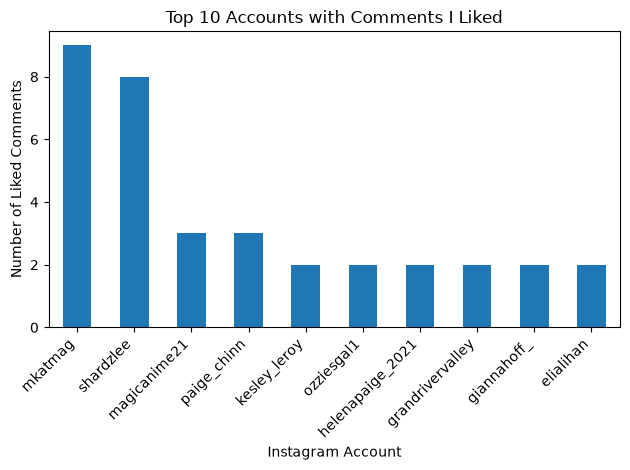

In [18]:
import matplotlib.pyplot as plt

comment_likes_by_account.head(10).plot(
    kind='bar',
    title='Top 10 Accounts with Comments I Liked'
)

plt.xlabel('Instagram Account')
plt.ylabel('Number of Liked Comments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Limitations

There are several limitations to this analysis. First, the datasets only contain certain types of Instagram activity, such as liked posts and liked comments. They do not represent every way I use Instagram. Second, the data does not explain why I liked a particular post or comment. A high number of interactions with an account does not necessarily mean that the account is one of my favorites or that I intentionally seek out its content.

The data may also have limitations related to the Instagram data export itself. Some of the text or emoji values may not display correctly, and I cannot independently verify whether every historical interaction was included in the downloaded files.


# Alternative Approaches

Another approach would be to analyze the dates of my interactions over time. I could group the data by month or year to see whether my Instagram activity has changed. I could also compare liked posts and liked comments to determine whether the same accounts appear frequently in both datasets.

# Next Steps

For future analysis, I could examine additional Instagram data files, such as saved posts, comments, or following information. Combining multiple datasets could provide a more complete picture of how I interact with Instagram.

I could also create a timeline showing how my activity changed over time. This could help identify periods when my Instagram activity increased or decreased and whether the accounts I interacted with changed.

# Conclusion

This report allowed me to examine my Instagram activity using personal data from my Instagram download. The liked_posts.json dataset shows the accounts whose posts I liked, while liked_comment.json provides information about comments that I liked.

The analysis of the liked-post data shows that my likes are not evenly distributed across all Instagram accounts. Some accounts appear much more frequently than others in the dataset. The second dataset allows me to examine whether a similar pattern appears in my interactions with comments.

Overall, the data provides evidence that my Instagram interactions can be concentrated among certain accounts. However, the data cannot explain why I interacted with those accounts or what caused the pattern. Therefore, the results describe my recorded Instagram activity but do not necessarily explain my motivations or overall Instagram behavior.